# GAN for MNIST

This notebook trains a small generative adversarial network. The generator creates candidate digit images while the discriminator learns to distinguish generated images from real MNIST examples.

janani
Epoch 1: generator=0.6991, discriminator=0.7639
Epoch 2: generator=2.0139, discriminator=0.1741


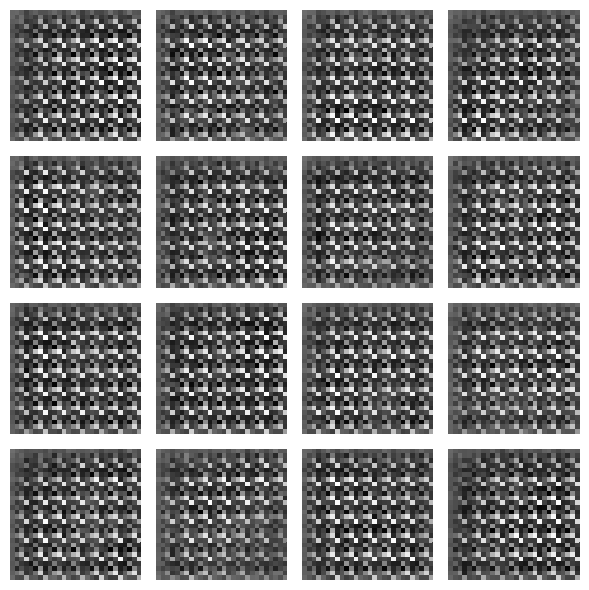

In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)
(images, _), _ = tf.keras.datasets.mnist.load_data()
images = (images[:10000].astype("float32") - 127.5) / 127.5
images = images[..., None]
dataset = tf.data.Dataset.from_tensor_slices(images).shuffle(10000).batch(128)

generator = models.Sequential([
	layers.Input(shape=(100,)),
	layers.Dense(7 * 7 * 128, use_bias=False),
	layers.BatchNormalization(), layers.LeakyReLU(),
	layers.Reshape((7, 7, 128)),
	layers.Conv2DTranspose(64, 5, strides=2, padding="same", use_bias=False),
	layers.BatchNormalization(), layers.LeakyReLU(),
	layers.Conv2DTranspose(1, 5, strides=2, padding="same", activation="tanh")
])
discriminator = models.Sequential([
	layers.Input(shape=(28, 28, 1)),
	layers.Conv2D(64, 5, strides=2, padding="same"), layers.LeakyReLU(), layers.Dropout(0.3),
	layers.Conv2D(128, 5, strides=2, padding="same"), layers.LeakyReLU(), layers.Dropout(0.3),
	layers.Flatten(), layers.Dense(1)
])
loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(real_images):
	noise = tf.random.normal((tf.shape(real_images)[0], 100))
	with tf.GradientTape() as generator_tape, tf.GradientTape() as discriminator_tape:
		generated_images = generator(noise, training=True)
		real_output = discriminator(real_images, training=True)
		fake_output = discriminator(generated_images, training=True)
		generator_loss = loss(tf.ones_like(fake_output), fake_output)
		discriminator_loss = loss(tf.ones_like(real_output), real_output) + loss(tf.zeros_like(fake_output), fake_output)
	generator_gradients = generator_tape.gradient(generator_loss, generator.trainable_variables)
	discriminator_gradients = discriminator_tape.gradient(discriminator_loss, discriminator.trainable_variables)
	generator_optimizer.apply_gradients(zip(generator_gradients, generator.trainable_variables))
	discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_variables))
	return generator_loss, discriminator_loss

for epoch in range(2):
	for batch in dataset:
		generator_loss, discriminator_loss = train_step(batch)
	print(f"Epoch {epoch + 1}: generator={generator_loss:.4f}, discriminator={discriminator_loss:.4f}")

samples = generator(tf.random.normal((16, 100)), training=False)
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for image, axis in zip(samples, axes.flat):
	axis.imshow((image[:, :, 0] + 1) / 2, cmap="gray")
	axis.axis("off")
plt.tight_layout()
plt.show()